# Taller 1  Supervisión de contratación pública de bienes (SECOP II)
**MINE-4101: Ciencia de Datos Aplicada 2026-20**

**Integrantes:** Iván Herrera - Mateo Jurado

**Objetivo:** Analizar los contratos de compra de bienes (compraventa y suministros) firmados por entidades públicas colombianas entre 2019 y 2025, para ayudar a la oficina de control interno a **focalizar su supervisión** hacia los contratos con mayor riesgo de desviarse del plan inicial (adiciones de plazo, ejecución presupuestal incompleta o cierre sin liquidar).

**Fuente:** SECOP II — Sistema Electrónico de Contratación Pública.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
RNG = 42


## 1. Entendimiento inicial de datos

Cargamos el dataset y revisamos su estructura general: dimensiones, tipos de datos, valores nulos y consistencia de las columnas clave.

In [2]:
df_raw = pd.read_parquet('../data/secop_bienes.parquet')
print(f"Dimensiones: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
df_raw.head(3)

Dimensiones: 196,391 filas x 36 columnas


,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,codigo_de_categoria_principal,objeto_del_contrato,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,duraci_n_del_contrato,condiciones_de_entrega,proveedor_adjudicado,documento_proveedor,es_pyme,es_grupo,g_nero_representante_legal,nacionalidad_representante_legal,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.50161509,Contratar a monto agotable por el sistema de p...,2019-06-19,2019-06-18,2019-12-31,No definido,Como acordado previamente,INDUSTRIAS GUERRERO Y COMPAÑIA S.A.S.,830130048,Si,No,No Definido,CO,17897916.0,17896237,17896237,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,V1.50131612,SUMINISTRO DE HUEVOS CON DESTINO A LOS COMEDOR...,2019-06-23,2019-06-13,2019-11-29,Dia(s),Transporte incluido,Distribuidora Antioqueña AM,21788564,Si,No,Mujer,CO,390000000.0,389999685,389999685,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.53102701,ADQUISICIÓN DE PRESILLAS BORDADAS AZULES EN CA...,2019-06-18,2019-06-24,2019-09-30,No definido,DAP - Entregado en un punto (lugar de destino ...,FANNY JANETH GUTIERREZ PRIETO,20484821,No,No,Mujer,CO,11970000.0,11970000,11970000,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...


In [3]:
df_raw.dtypes.to_frame('tipo_de_dato')

,tipo_de_dato
id_contrato,str
nombre_entidad,str
departamento,str
ciudad,str
orden,str
sector,str
rama,str
entidad_centralizada,str
tipo_de_contrato,str
modalidad_de_contratacion,str


In [4]:
# Valores nulos por columna (%)
nulos = (df_raw.isna().mean()*100).round(2).sort_values(ascending=False)
nulos[nulos>0]

fecha_de_inicio_del_contrato    1.24
dtype: float64

Solo `fecha_de_inicio_del_contrato` presenta nulos explícitos (~1.2%). Sin embargo, varias columnas categóricas usan la etiqueta literal **"No Definido"** o **"No aplica"** como un nulo disfrazado — se tratan más adelante como categoría de "dato no reportado", no se imputan, porque en datos administrativos su ausencia es en sí misma informativa (ej. una entidad que no diligencia el destino del gasto).

### Selección de los 5 atributos más relevantes

Elegimos estos 5 atributos porque son exactamente los que menciona el enunciado del taller como relevantes para detectar desviaciones y porque, según nuestra exploración inicial, son los que más varianza explican en los indicadores de desviación (ver sección 3):

| # | Variable | Descripción | Tipo |
|---|----------|--------------|------|
| 1 | `valor_del_contrato` | Tamaño económico del contrato | Numérica continua |
| 2 | `modalidad_de_contratacion` | Mecanismo de selección del proveedor | Categórica |
| 3 | `sector` | Sector administrativo al que pertenece la entidad contratante | Categórica |
| 4 | `dias_adicionados` | Días de prórroga acumulados al contrato (proxy directo de desviación de plazo) | Numérica discreta |
| 5 | `destino_gasto` | Funcionamiento vs. inversión | Categórica |

A continuación, el análisis univariado de cada uno.

In [5]:
print(df_raw['valor_del_contrato'].describe().apply(lambda x: f"{x:,.0f}"))
print()
print("Contratos con valor <= 0:", (df_raw['valor_del_contrato']<=0).sum())
p999 = df_raw.loc[df_raw['valor_del_contrato']>0,'valor_del_contrato'].quantile(0.999)
print(f"Percentil 99.9: {p999:,.0f}  |  Máximo: {df_raw['valor_del_contrato'].max():,.0f}")
print("Contratos por encima del percentil 99.9:", (df_raw['valor_del_contrato']>p999).sum())

count                   196,391
mean             65,824,255,028
std          29,015,352,967,837
min                           0
25%                  12,021,214
50%                  33,600,000
75%                 100,000,000
max      12,858,450,316,000,000
Name: valor_del_contrato, dtype: str

Contratos con valor <= 0: 188
Percentil 99.9: 31,000,990,678  |  Máximo: 12,858,450,316,000,000
Contratos por encima del percentil 99.9: 197


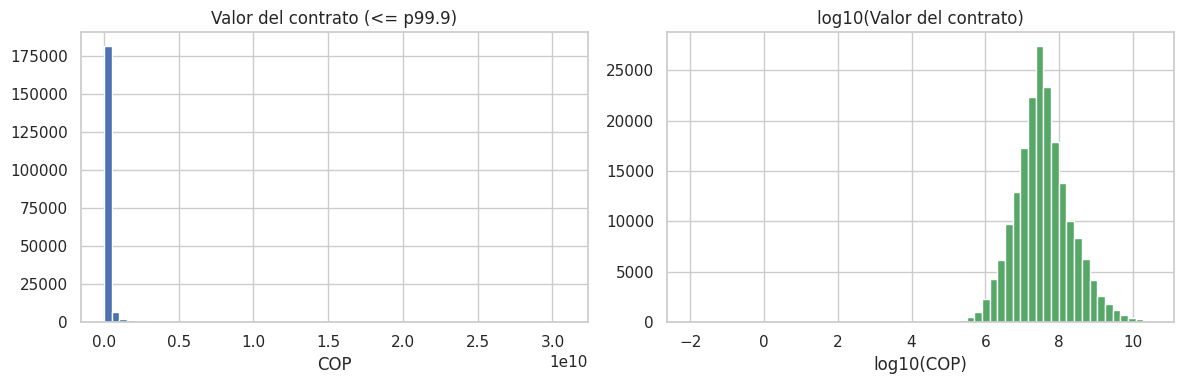

In [6]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
vals = df_raw.loc[(df_raw['valor_del_contrato']>0)&(df_raw['valor_del_contrato']<=p999),'valor_del_contrato']
axes[0].hist(vals, bins=60, color='#4C72B0')
axes[0].set_title('Valor del contrato (<= p99.9)')
axes[0].set_xlabel('COP')
axes[1].hist(np.log10(vals), bins=60, color='#55A868')
axes[1].set_title('log10(Valor del contrato)')
axes[1].set_xlabel('log10(COP)')
plt.tight_layout(); plt.show()

**Hallazgo:** la distribución de `valor_del_contrato` es extremadamente asimétrica a la derecha (típico de montos monetarios), con una mediana de ~\$33.6M COP frente a una media de ~\$65.8 mil millones — completamente distorsionada por un puñado de valores claramente erróneos (uno de ellos supera los 12 mil billones de COP, imposible para un contrato de bienes). En log10 la distribución es mucho más cercana a una normal, confirmando que el problema es de escala/outliers, no de la variable en sí.

modalidad_de_contratacion
Mínima cuantía                                                 60.0
Selección abreviada subasta inversa                            16.8
Contratación régimen especial                                   9.8
Selección Abreviada de Menor Cuantía                            4.5
Contratación régimen especial (con ofertas)                     3.1
Contratación Directa (con ofertas)                              2.5
Contratación directa                                            2.0
Licitación pública                                              1.2
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes     0.1
Name: count, dtype: float64


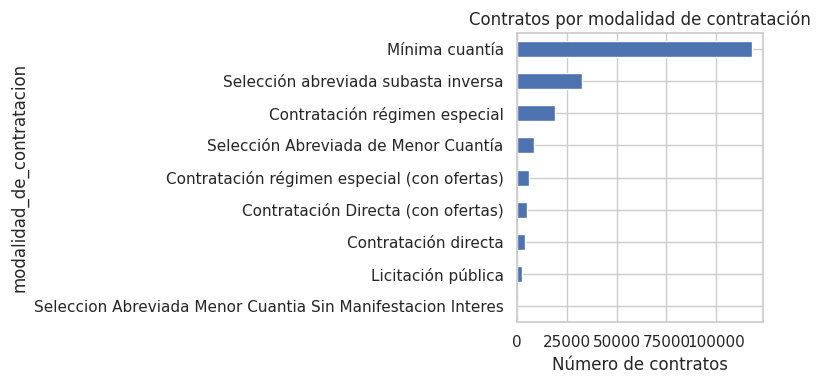

In [7]:
mod_counts = df_raw['modalidad_de_contratacion'].value_counts()
print((mod_counts/len(df_raw)*100).round(1))

fig, ax = plt.subplots(figsize=(8,4))
mod_counts.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Número de contratos'); ax.set_title('Contratos por modalidad de contratación')
plt.tight_layout(); plt.show()

**Hallazgo:** el 60% de los contratos se firman por **Mínima cuantía**, la modalidad más simple/ágil reservada para montos pequeños, seguida de subasta inversa (16.8%) y régimen especial (9.8%). La alta concentración en mínima cuantía es esperable dado que el dataset cubre *bienes* (compras rutinarias), pero implica que el volumen de supervisión manual no puede centrarse solo en contratos grandes/licitados: hay que usar reglas automatizadas para el grueso del universo.

sector
Servicio Público                    37390
defensa                             34585
No aplica/No pertenece              24465
Salud y Protección Social           22037
Ley de Justicia                     20377
Trabajo                             14759
Educación Nacional                  10231
Ambiente y Desarrollo Sostenible     8109
Transporte                           4655
Cultura                              2792
Name: count, dtype: int64


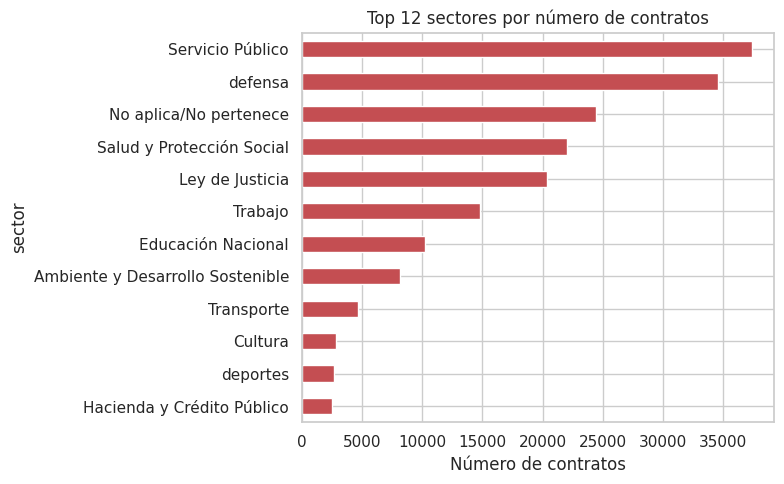

In [8]:
sec_counts = df_raw['sector'].value_counts()
print(sec_counts.head(10))

fig, ax = plt.subplots(figsize=(8,5))
sec_counts.head(12).sort_values().plot(kind='barh', ax=ax, color='#C44E52')
ax.set_xlabel('Número de contratos'); ax.set_title('Top 12 sectores por número de contratos')
plt.tight_layout(); plt.show()

**Hallazgo:** los sectores con más contratos de bienes son *Servicio Público* (19%), *defensa* (17.6%) y *Salud y Protección Social* (11.2%). El sector *defensa* concentra fuerte peso en entidades como el Ejército, lo cual es relevante porque, como se ve en la sección 3, estos sectores muestran patrones de desviación muy distintos entre sí.

count    196391.000000
mean          5.107485
std          40.662426
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       14276.000000
Name: dias_adicionados, dtype: float64

Contratos con dias_adicionados > 0: 18671 (9.5%)


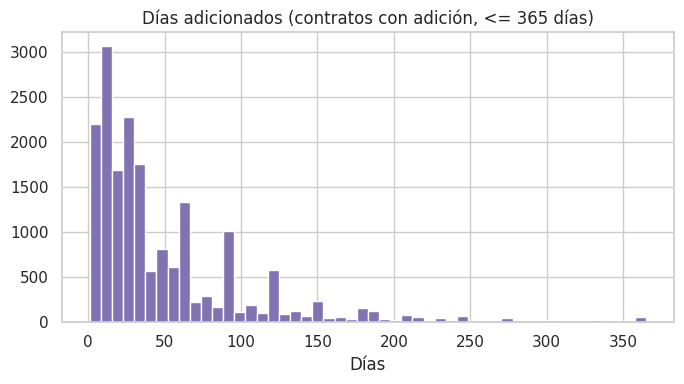

In [9]:
print(df_raw['dias_adicionados'].describe())
print()
print("Contratos con dias_adicionados > 0:", (df_raw['dias_adicionados']>0).sum(),
      f"({(df_raw['dias_adicionados']>0).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7,4))
sub = df_raw.loc[(df_raw['dias_adicionados']>0)&(df_raw['dias_adicionados']<=365),'dias_adicionados']
ax.hist(sub, bins=50, color='#8172B2')
ax.set_title('Días adicionados (contratos con adición, <= 365 días)')
ax.set_xlabel('Días'); plt.tight_layout(); plt.show()

**Hallazgo:** solo el 9.5% de los contratos recibe adición de plazo, pero cuando ocurre, la mediana de la adición se concentra en pocos meses — con una cola larga de casos extremos (hasta 14,276 días, es decir, ~39 años, casi con certeza un error de digitación o un caso atípico que merece revisión manual puntual). `dias_adicionados` es nuestro proxy más directo de "desviación de plazo".

destino_gasto
Funcionamiento    59.6
Inversión         39.9
No aplica          0.3
No Definido        0.2
Name: count, dtype: float64


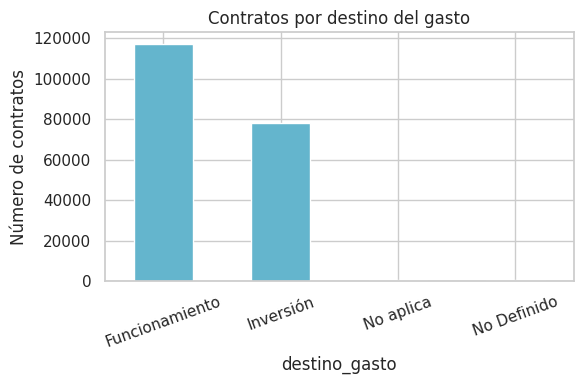

In [10]:
dg = df_raw['destino_gasto'].value_counts()
print((dg/len(df_raw)*100).round(1))

fig, ax = plt.subplots(figsize=(6,4))
dg.plot(kind='bar', ax=ax, color='#64B5CD')
ax.set_ylabel('Número de contratos'); ax.set_title('Contratos por destino del gasto')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

**Hallazgo:** 59.6% de los contratos son de *Funcionamiento* y 39.9% de *Inversión*. Esta distinción importa porque los recursos de inversión suelen tener reglas de ejecución y liquidación más estrictas (y en general, mayor escrutinio político), lo que hipotetizamos que se asocia con distinto comportamiento de desviación.

### Problemas de calidad de datos identificados y tratamiento

| Problema | Magnitud | Tratamiento |
|---|---|---|
| `valor_del_contrato` ≤ 0 | 188 contratos (0.10%) | Se excluyen de los análisis basados en valor (no son compras reales válidas) |
| `valor_del_contrato` con outliers extremos de digitación (ej. 1.28×10¹⁶) | 197 contratos por encima del percentil 99.9 | Se excluyen del análisis cuantitativo de valor (se documentan como casos a revisar manualmente, no se imputan ni se inventan valores) |
| `fecha_de_fin_del_contrato` anterior a `fecha_de_inicio_del_contrato` | 125 contratos (0.06%) | Se excluyen de los análisis que usan fechas/duración, por inconsistencia lógica |
| `fecha_de_inicio_del_contrato` nula | ~1.2% | Se conservan (no afecta los indicadores usados); se excluyen únicamente de cálculos que requieran esa fecha puntual |
| Categorías "No Definido" / "No aplica" en columnas categóricas (`sector`, `destino_gasto`, `habilita_pago_adelantado`, etc.) | Variable por columna (0.2%–14.5%) | Se conservan como categoría propia ("no reportado"), no se imputan — su ausencia es informativa en un dataset administrativo |
| Ventana temporal de 7 años no directamente comparable (contratos recientes no han tenido tiempo de liquidarse/cerrarse) | Ver sección 3 | Se define una ventana de análisis explícita para los indicadores de desviación que dependen del ciclo de vida del contrato |

Ningún registro se imputa numéricamente (no se rellenan valores faltantes con medias/medianas): en datos de contratación pública, "inventar" un valor de contrato o una fecha puede introducir sesgos que llevarían a conclusiones de supervisión equivocadas. Preferimos excluir explícitamente y documentar cuántos registros se pierden en cada paso.

In [11]:
# Aplicamos la limpieza descrita arriba y creamos el dataset de trabajo (dfc)
dfc = df_raw.copy()
dfc = dfc[dfc['valor_del_contrato'] > 0]
p999 = dfc['valor_del_contrato'].quantile(0.999)
dfc = dfc[dfc['valor_del_contrato'] <= p999]
dfc = dfc[dfc['fecha_de_fin_del_contrato'] >= dfc['fecha_de_inicio_del_contrato']]
dfc['anio_firma'] = dfc['fecha_de_firma'].dt.year

print(f"Registros originales: {len(df_raw):,}")
print(f"Registros tras limpieza: {len(dfc):,}  ({len(dfc)/len(df_raw)*100:.1f}% retenido)")

Registros originales: 196,391
Registros tras limpieza: 193,445  (98.5% retenido)


## 2. Estrategia de análisis

Definimos la **desviación de un contrato** operacionalmente a partir de tres indicadores directamente derivables del dataset, cada uno asociado a uno de los síntomas descritos en el contexto de negocio: (i) **adición de plazo** (`dias_adicionados > 0`), que refleja incumplimiento del cronograma inicial; (ii) **ejecución presupuestal incompleta** (`valor_pagado` < 90% de `valor_del_contrato` en contratos ya finalizados), que refleja que el presupuesto comprometido no se ejecutó; y (iii) **cierre sin liquidar** (`liquidacion == "No"` en contratos con estado `terminado`/`Cerrado`), que refleja procesos administrativos que quedan inconclusos. No los combinamos en un único índice porque, como se muestra más adelante, son prácticamente independientes entre sí (correlación < 0.05) y cada uno responde a una causa distinta — mezclarlos en un solo "score" oscurecería cuál factor está fallando y le restaría utilidad accionable a la oficina de control interno.

Como los indicadores (ii) y (iii) solo pueden observarse una vez el contrato termina su ciclo de vida, y los contratos firmados en 2024–2025 aún no han tenido tiempo suficiente para cerrarse (verificado empíricamente: la tasa de contratos "finalizados" cae de ~53-60% en 2019-2023 a 36.6% en 2025), restringimos el análisis de estos dos indicadores a contratos **firmados entre 2019 y 2023**, evitando así una censura por derecha que subestimaría artificialmente el problema en los años más recientes. El indicador de plazo adicionado se calcula sobre esa misma ventana para todos los contratos (finalizados o no), ya que una adición de plazo, una vez ocurre, queda registrada independientemente del estado actual del contrato.

Con esta base, calculamos estadísticos descriptivos univariados (sección 1) y luego cruzamos cada indicador de desviación con los atributos estructurales del contrato — modalidad de contratación, sector, orden de la entidad, destino del gasto, tipo de proveedor (PyME) y valor del contrato — usando **pruebas de hipótesis explícitas**: chi-cuadrado de independencia para pares categóricos, U de Mann-Whitney para comparar `valor_del_contrato` (variable con distribución muy asimétrica, por lo que evitamos t-test paramétrico) entre grupos con y sin desviación, y Kruskal-Wallis para comparar `dias_adicionados` entre las distintas modalidades. Dado el tamaño de muestra (>60,000 contratos en la ventana de análisis), casi cualquier diferencia resulta estadísticamente significativa; por eso complementamos cada prueba significativa con el tamaño de efecto (V de Cramér) para distinguir significancia estadística de relevancia práctica antes de traducir los hallazgos en criterios de focalización.